
# Level 1  Task 2 Stock Prices


Simple Linear Regression**: build and evaluate a linear regression model to predict the **`close`** price.



In [111]:


import numpy as np
import pandas as pd


In [112]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [86]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt




## Task 1 — Data Preprocessing

In [87]:
df = pd.read_csv('stock_prices_data_set.csv')


# analyze shape of dataset

In [88]:
print("Shape:", df.shape)


Shape: (497472, 7)


# show first 5 rows

In [89]:
df.head()


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


# show data types of all the columns

In [90]:
df.dtypes

,0
symbol,object
date,object
open,float64
high,float64
low,float64
close,float64
volume,int64


# create time features for temporal patterns

In [91]:


if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek  # Monday=0



In [92]:
print(df.dtypes)


symbol               object
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
volume                int64
year                  int32
month                 int32
day                   int32
dayofweek             int32
dtype: object


In [93]:
df.head()

,symbol,date,open,high,low,close,volume,year,month,day,dayofweek
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2014,1,2,3
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2014,1,2,3
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2014,1,2,3
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2014,1,2,3
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2014,1,2,3


###  Explore missing values

In [94]:

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


,0
open,11
low,8
high,8


## 1.3 Visualisation de la Distribution des Données

Pour mieux comprendre la répartition de chaque caractéristique numérique, nous allons visualiser leurs distributions à l'aide d'histogrammes.

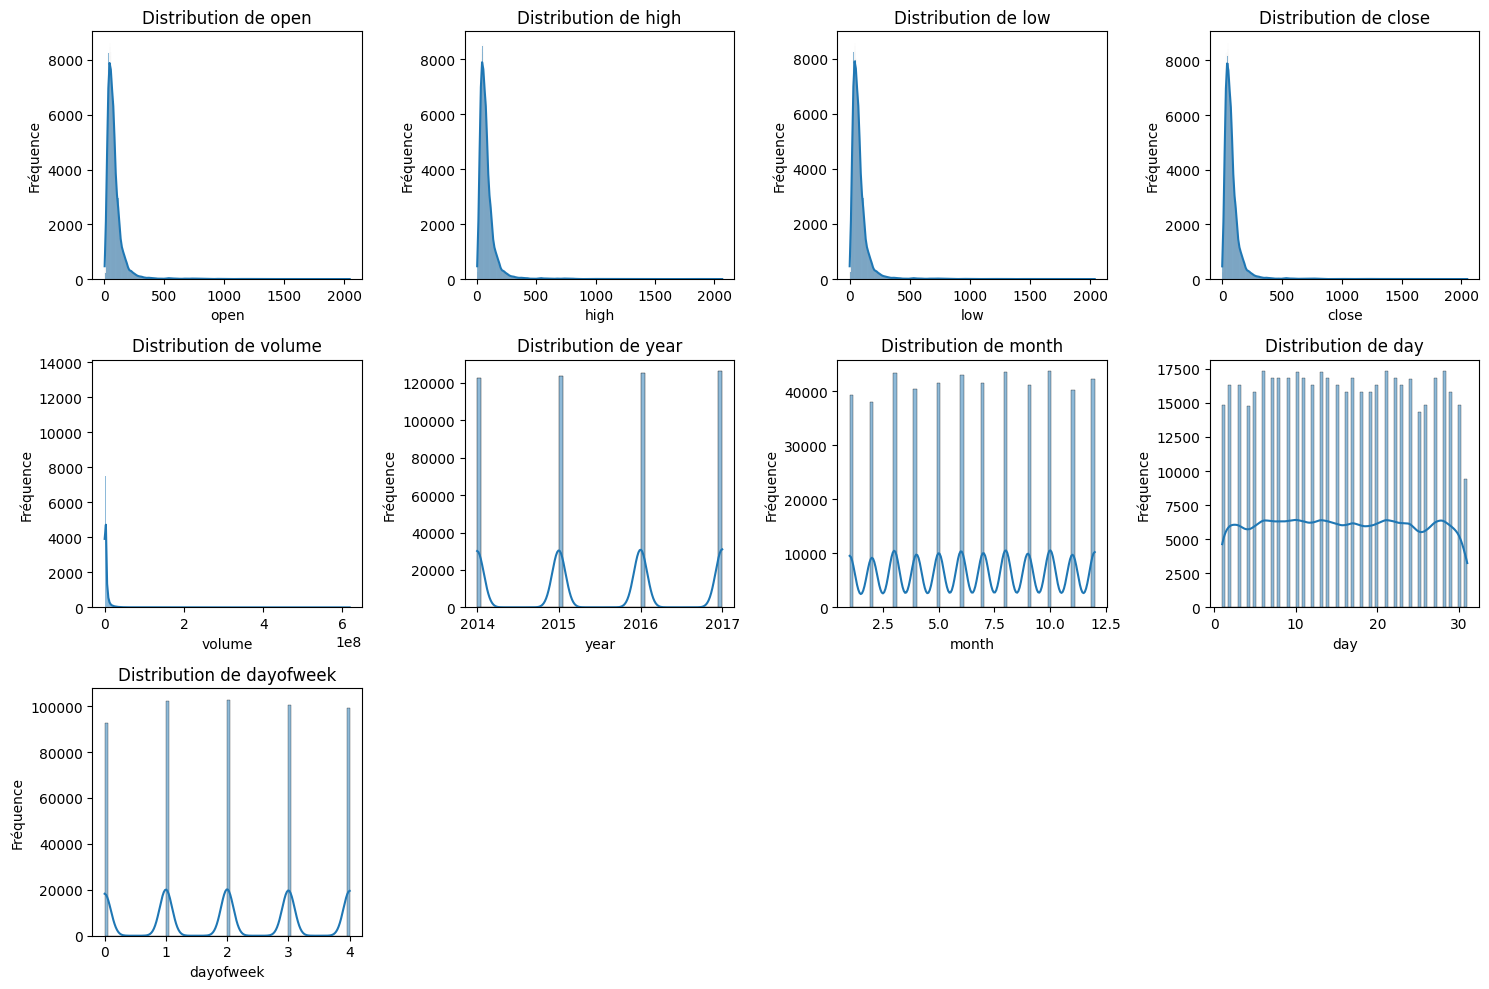

In [95]:

import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = df.select_dtypes(include=['number']).columns

# Créer des histogrammes
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()


## Identification de la Cible et des Caractéristiques


Définir la colonne cible ('close') et identifier les caractéristiques d'entrée (toutes les colonnes sauf 'close' et 'date'). Gérer les valeurs manquantes dans la colonne cible en supprimant les lignes correspondantes.


In [96]:
target_col = "close"

In [97]:
df = df.dropna(subset=[target_col])

In [98]:

X = df.drop([target_col, "date"], axis=1)
y = df[target_col]



### 1.5 Identify numeric & categorical columns

In [99]:

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()




### 1.6 splitting Input and target features into train and test data

In [100]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 1.7 Build preprocessing pipelines

# creating a pipeline for preprocessing numeric features.

In [101]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



# creating a pipeline for preprocessing categorical features.

In [102]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# building a column transformer for numeric and categorical features

In [103]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)



## Simple Linear Regression Model

### 1.4 Matrice de Corrélation des Caractéristiques Numériques

Nous allons visualiser la matrice de corrélation pour comprendre les interrelations entre les différentes caractéristiques numériques et leur relation avec la variable cible 'close'. Une heatmap est un excellent moyen de représenter ces corrélations.

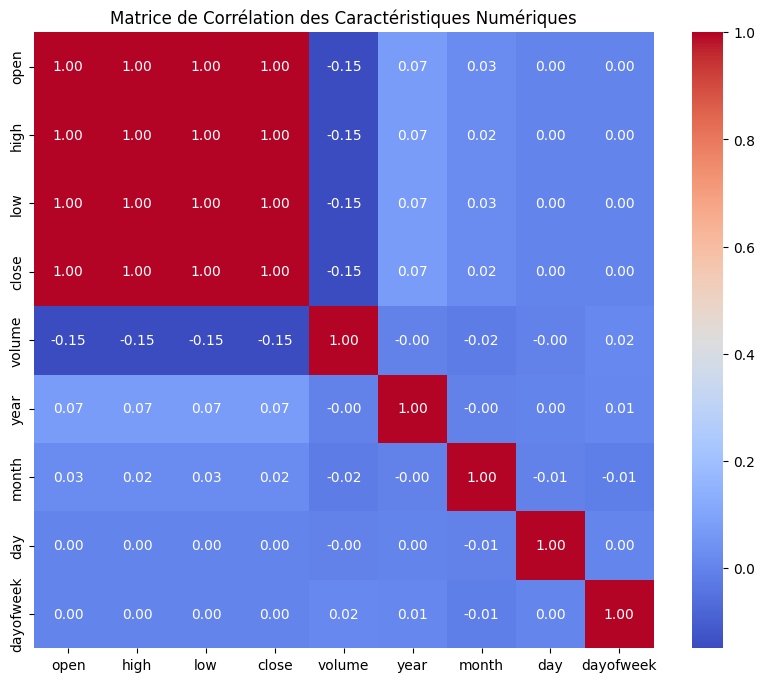

In [104]:

import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['number'])


correlation_matrix = numeric_df.corr()

#  heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Caractéristiques Numériques')
plt.show()


# making the object of linear regression

In [105]:
linreg = LinearRegression()

In [106]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', linreg)
])


### 2.2 Train the model on training data

In [107]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['open', 'high', 'low',
                                                   'volume']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['symbol'])])),
                ('regressor', LinearRegression())])

# first predict on test data

In [108]:
y_pred = model.predict(X_test)
y_pred

array([104.33212606,  70.89053016,  47.27547286, ...,  71.52012191,
        58.46581019, 162.82312969])

# print the evalution metrics result

In [109]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

R-squared: 0.9999495885068687
MSE: 0.5226108411112547
RMSE: 0.7229182810741852


### 2.4 Predicted vs Actual plot

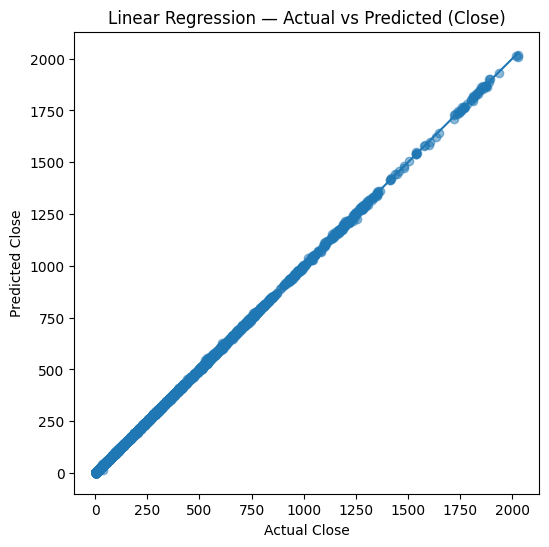

In [110]:

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.title("Linear Regression — Actual vs Predicted (Close)")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()


## Summary:

### Data Analysis Key Findings

*   The initial data preparation successfully loaded the `stock_prices_data_set.csv` and engineered new temporal features (year, month, day, dayofweek) from the 'date' column.
*   The 'close' price was designated as the target variable, and missing values within this column were effectively handled by removing relevant rows.
*   The linear regression model demonstrated exceptionally strong performance in predicting stock 'close' prices.
*   Key performance metrics include an R-squared (R2) value of 0.99995, indicating that approximately 99.995% of the variance in 'close' prices is explained by the model.
*   The model achieved a Mean Squared Error (MSE) of 0.5226 and a Root Mean Squared Error (RMSE) of 0.7229, signifying a very low average prediction error and high accuracy.
*   Visualizations confirmed the strong performance, showing actual versus predicted 'close' prices closely aligning with the perfect prediction line (y=x).

